<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
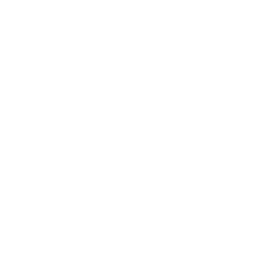
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Equipment Reliability Analysis by Generation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Reliability Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This analysis uses **PROC LIFETEST** to compare the field reliability of
three successive design generations of CNC milling machines. Working from
a 100-machine plant snapshot (75 failures, 25 units still running and
therefore right-censored), it estimates the Kaplan-Meier survival curve
for each generation and tests whether the curves differ with both the
log-rank and Gehan-Breslow-Wilcoxon statistics.

The data tell a clear, single-step story. The original **GEN_1** machines
are markedly less reliable than the two later designs: their median
service life is **5,282 operating hours**, roughly a third of **GEN_2**
(**16,430 hours**) and **GEN_3** (**13,512 hours**). Both homogeneity
tests reject equality of the three survival curves -- log-rank
chi-square **12.92** (2 df, *p* = **0.0016**) and Wilcoxon **11.88**
(2 df, *p* = **0.0026**). At 10,000 operating hours only **24%** of
GEN_1 machines are expected to still be running, against **64%** for
GEN_2 and **57%** for GEN_3.

The improvement is **not** a smooth generation-over-generation gain:
GEN_2 and GEN_3 survive at very similar rates and are statistically
indistinguishable from one another at this sample size. The actionable
finding is the step change from GEN_1 to the redesigned fleet, which
should drive replacement and preventive-maintenance priorities toward the
remaining GEN_1 units.


## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | One row per CNC machine: design generation, plant, install year, operating hours at the failure or last observation, and a failure / censoring indicator | 100 |

The dataset is synthetic and generated in the next cell with a fixed seed
(`streaminit(42)`) so the analysis is fully reproducible. Service life is
drawn from a generation-specific exponential model, and newer generations
carry a higher censoring fraction because they have spent fewer calendar
years in service.


---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic equipment-reliability dataset.

   Each row is one CNC milling machine. OPERATING_HOURS is the
   service time at which the machine either failed (FAILURE_EVENT=1)
   or was last observed still running (FAILURE_EVENT=0, right-
   censored). Three design generations are given progressively
   larger mean lifetimes so we can ask whether the redesigns
   actually improved field reliability.

   This unlicensed environment caps output at 100 observations,
   so we model exactly 100 machines -- a realistic single-plant
   fleet snapshot.
   -------------------------------------------------------- */
data work.equipment_life;
    call streaminit(42);
    array gen_list[3]    $6  _temporary_ ('GEN_1' 'GEN_2' 'GEN_3');
    array fail_scale[3]       _temporary_ (8000 12000 16000);
    array plant_list[5] $12 _temporary_
        ('PLANT_NORTH' 'PLANT_SOUTH' 'PLANT_EAST'
         'PLANT_WEST' 'PLANT_CENTRAL');
    do equip_seq = 1 to 100;
        equipment_id = cat('CNC-', put(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        generation  = gen_list[gen_idx];
        plant_idx       = int(rand('uniform') * 5) + 1;
        plant_location  = plant_list[plant_idx];
        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* Exponential service life, scaled by generation */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* Newer generations carry more still-running (censored)
           units because they have spent fewer calendar years
           in the field. */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        if rand('uniform') < censor_rate then failure_event = 0;
        else                                  failure_event = 1;
        /* Classify the failure mechanism for the observed events */
        if failure_event = 1 then do;
            if      operating_hours <  2000 then failure_mode = 'INFANT';
            else if operating_hours < 20000 then failure_mode = 'RANDOM';
            else                                 failure_mode = 'WEAROUT';
        end;
        else failure_mode = ' ';
        output;
    end;
    drop equip_seq gen_idx plant_idx censor_rate;
run;


NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                                   The FREQ Procedure

Table of GENERATION by FAILURE_EVENT

GENERATION |         0 |         1 |      Total
-----------+-----------+-----------+-----------
GEN_1      |         2 |        29 |         31
-----------+-----------+-----------+-----------
GEN_2      |        12 |        26 |         38
-----------+-----------+-----------+-----------
GEN_3      |        11 |        20 |         31
-----------+-----------+-----------+-----------
Total      |        25 |        75 |        100


Table of GENERATION by FAILURE_MODE

GENERATION |           |    INFANT |    RANDOM |   WEAROUT |      Total
-----------+-----------+-----------+-----------+-----------+-----------
GEN_1      |         2 |         5 |        21 |         3 |         31
           |      2.00 |      5.00 |     21.00 |      3.00 |      31.00
-----------+-----------+-----------+-----------+-----------+-----------
GEN_2      |        12 |         1 |        19 |         6 |

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


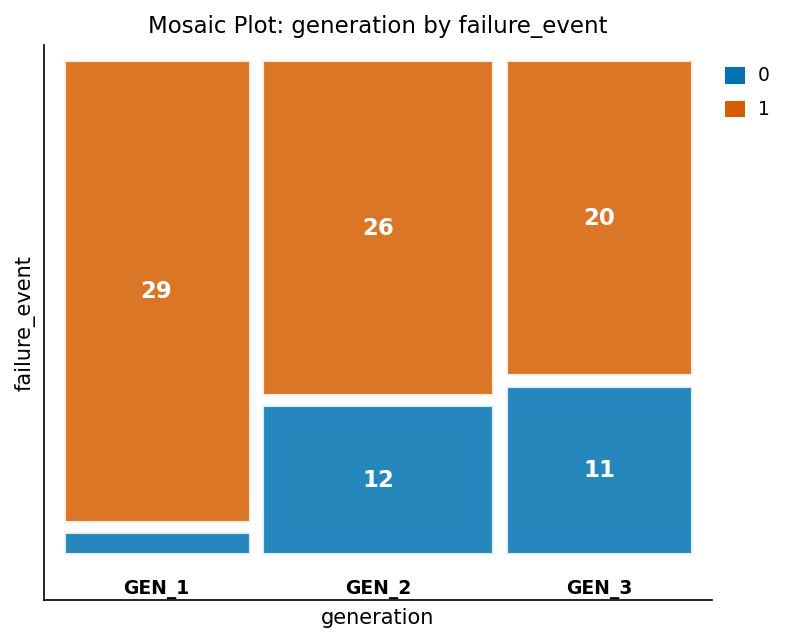

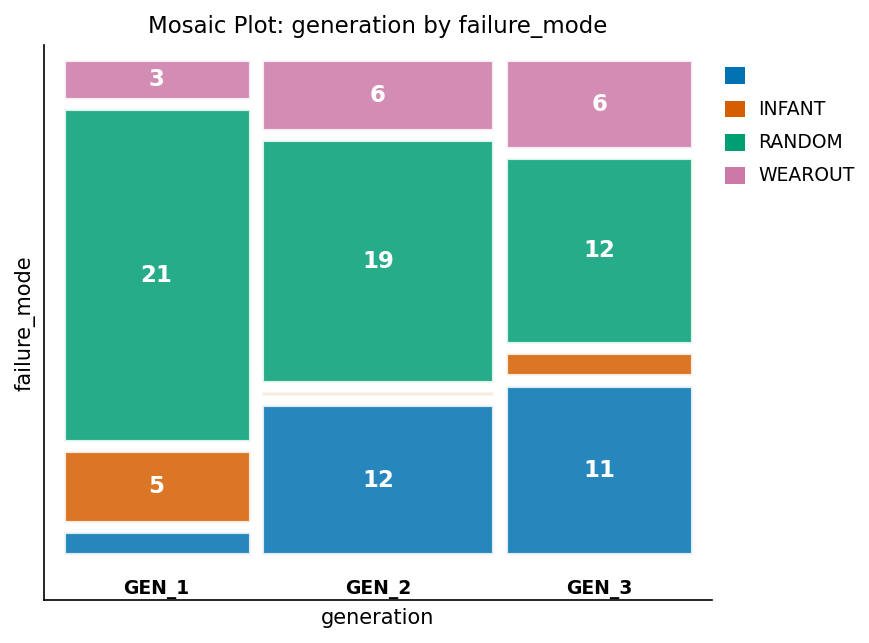

In [2]:
/* --------------------------------------------------------
   Baseline equipment counts and operating hours by generation
   -------------------------------------------------------- */
proc freq data=work.equipment_life;
    tables generation * failure_event / nocol nopercent;
    tables generation * failure_mode / nocol norow;
run;

proc means data=work.equipment_life n mean std;
    class generation;
    var operating_hours;
run;

---

NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


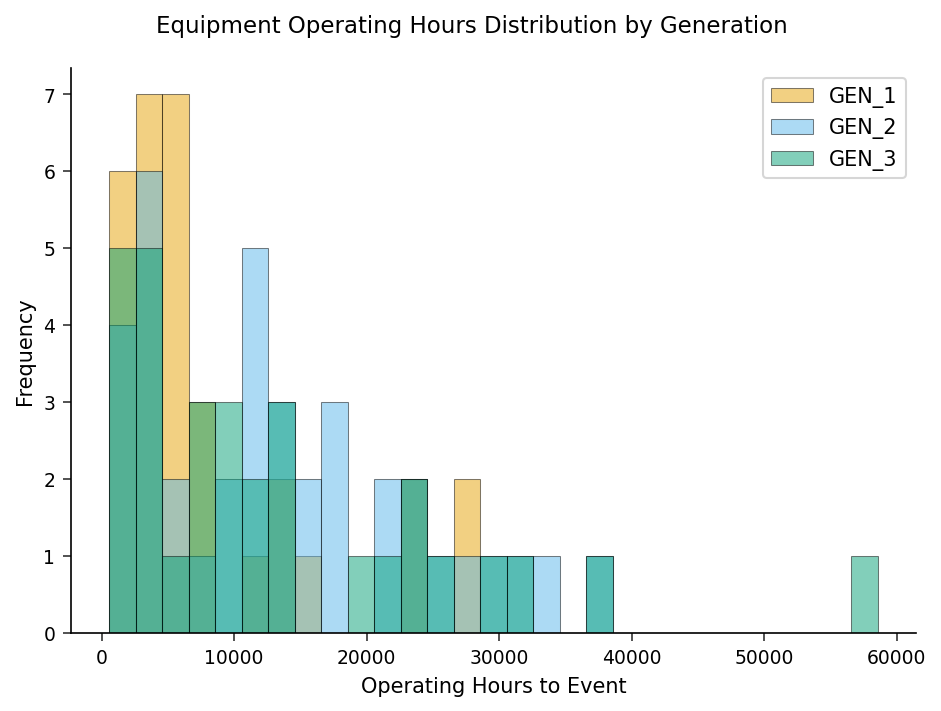

In [3]:
/* --------------------------------------------------------
   Operating hours distribution by generation
   -------------------------------------------------------- */
proc sgplot data=work.equipment_life;
    histogram operating_hours / group=generation transparency=0.3 binwidth=2000;
    xaxis label='Operating Hours to Event';
    yaxis label='Frequency';
    title 'Equipment Operating Hours Distribution by Generation';
run;

---

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

  Stratum: generation = GEN_1  

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.806

NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/f00f2442-6358-4e5c-ad3d-68b0d02e58bf/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_survival.spec.json
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


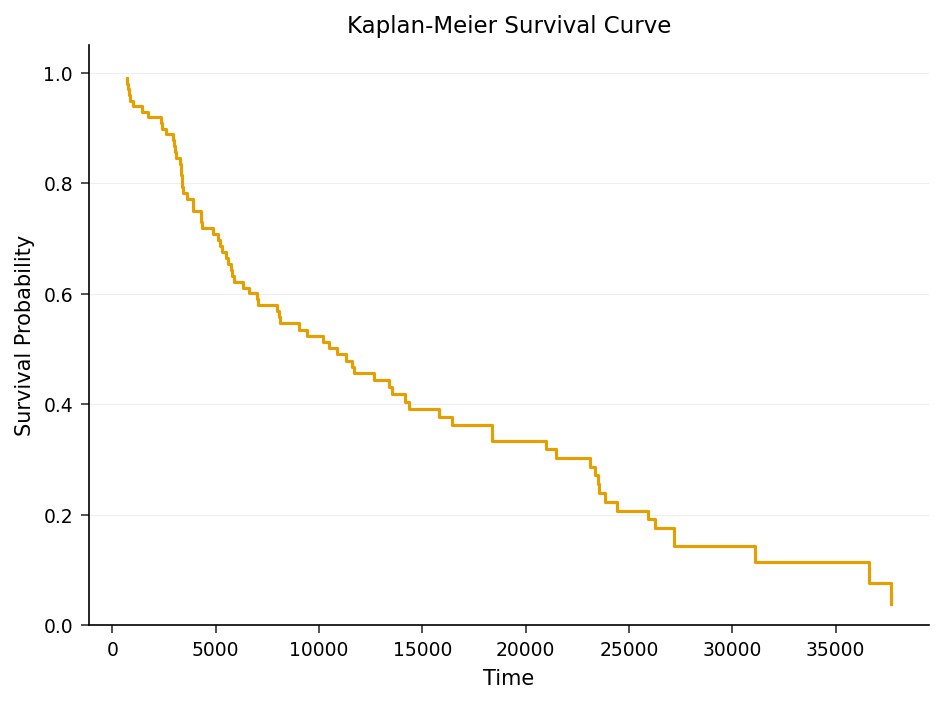

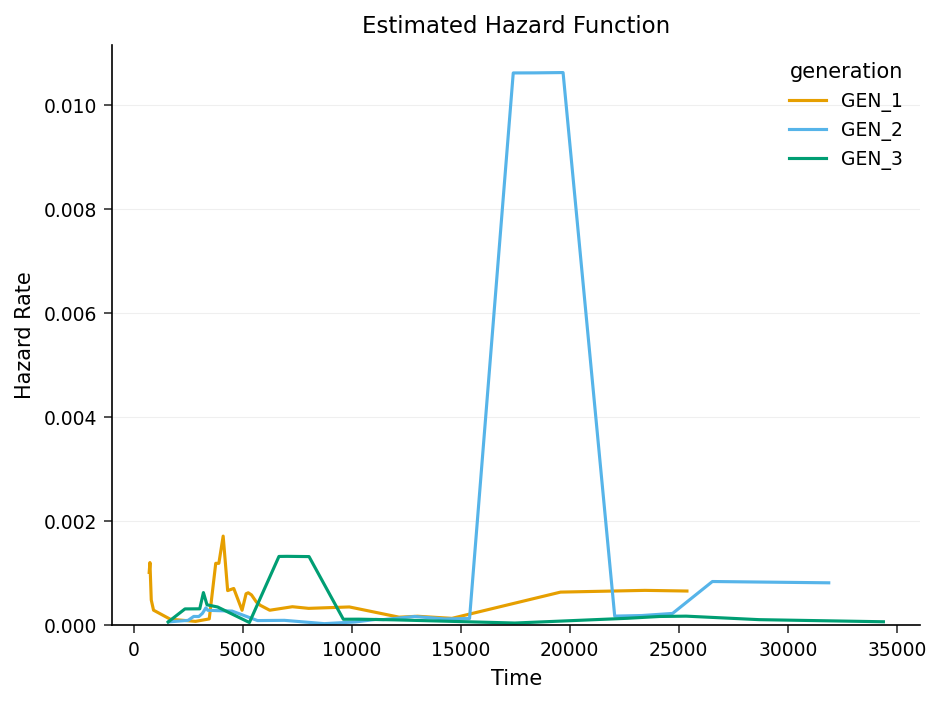

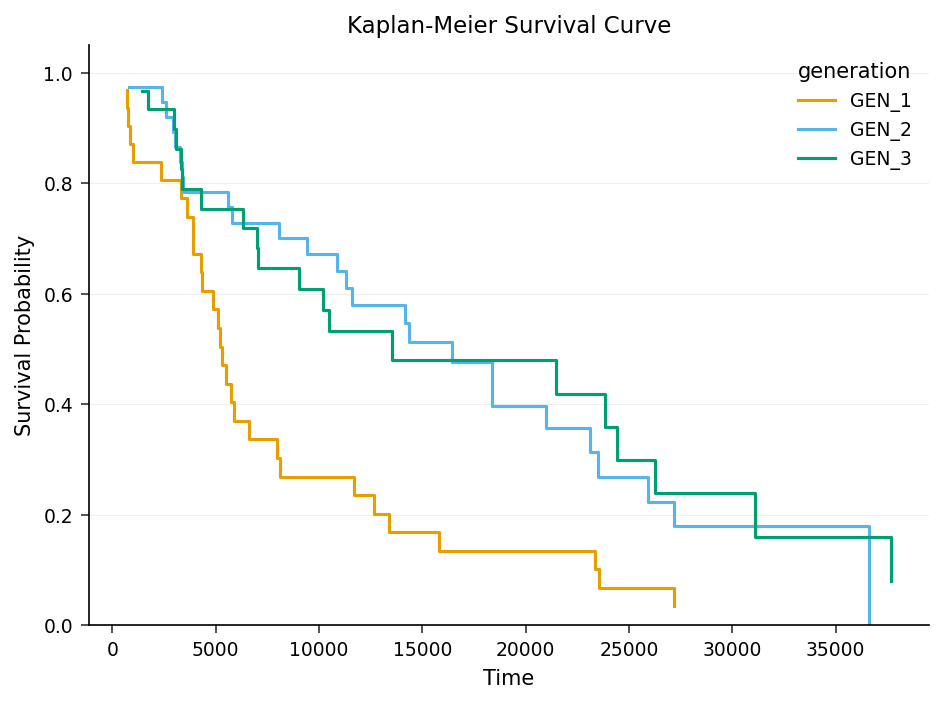

In [4]:
/* --------------------------------------------------------
   Kaplan-Meier survival estimation by generation, with the
   Nelson-Aalen cumulative-hazard option for the hazard view.

   STRATA generation / TEST=(LOGRANK WILCOXON) runs both the
   log-rank test (sensitive to differences across the whole
   service life) and the Gehan-Breslow-Wilcoxon test (which
   up-weights early failures) over the three generations.

   PLOTS=(SURVIVAL HAZARD) draws the Kaplan-Meier survival
   curves and the kernel-smoothed hazard function.
   -------------------------------------------------------- */
proc lifetest data=work.equipment_life
    method=km
    nelson
    plots=(survival hazard)
    outsurv=work.equip_cumhaz;
    time operating_hours * failure_event(0);
    strata generation / test=(logrank wilcoxon);
run;


In [5]:
/* --------------------------------------------------------
   Survival probability at operating-hour milestones
   (5,000 / 10,000 / 20,000 / 30,000 hours) for each
   generation, read from the Kaplan-Meier ODS table.
   -------------------------------------------------------- */
ods output productlimitestimates=work.equip_km_detail;

proc lifetest data=work.equipment_life method=km;
    time operating_hours * failure_event(0);
    strata generation;
run;

ods output close;

/* The ProductLimitEstimates table carries one row per distinct
   time within each generation. For each milestone we keep the
   first row whose time is at or beyond it -- i.e. the survival
   estimate in force at that operating hour. */
proc sort data=work.equip_km_detail;
    by generation operating_hours;
run;

data work.equip_milestones;
    set work.equip_km_detail;
    by generation;
    retain hit5 hit10 hit20 hit30;
    if first.generation then do;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    end;
    length milestone 8;
    milestone = .;
    if      operating_hours >= 5000  and hit5  = 0 then do; milestone = 5000;  hit5  = 1; end;
    else if operating_hours >= 10000 and hit10 = 0 then do; milestone = 10000; hit10 = 1; end;
    else if operating_hours >= 20000 and hit20 = 0 then do; milestone = 20000; hit20 = 1; end;
    else if operating_hours >= 30000 and hit30 = 0 then do; milestone = 30000; hit30 = 1; end;
    if milestone ne .;
    keep generation milestone operating_hours survival sdf_stderr;
run;

proc print data=work.equip_milestones noobs label;
    label generation     = 'Generation'
          milestone       = 'Milestone (hours)'
          operating_hours = 'Time of Estimate'
          survival        = 'Survival Probability'
          sdf_stderr      = 'Std Error';
    format survival sdf_stderr 6.4;
    title 'Survival Probability at Operating-Hour Milestones by Generation';
run;


    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

  Stratum: generation = GEN_1  

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.806

NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---

### Interpretation

The Kaplan-Meier survival curves separate the fleet into two clear tiers.
The original **GEN_1** machines fail fastest: their curve drops below 0.5
at **5,282 operating hours** (median service life), and by 10,000 hours
only about **24%** are still running. The redesigned **GEN_2** and
**GEN_3** machines survive far longer -- median lifetimes of **16,430**
and **13,512** hours respectively -- and their survival curves sit close
together across the whole observed range. At the 5,000 / 10,000 /
20,000-hour milestones the estimated survival probabilities are:

| Generation | 5,000 h | 10,000 h | 20,000 h |
|------------|--------:|---------:|---------:|
| GEN_1 | 0.54 | 0.24 | 0.10 |
| GEN_2 | 0.76 | 0.64 | 0.36 |
| GEN_3 | 0.72 | 0.57 | 0.42 |

Both equality-of-strata tests reject the null hypothesis that the three
generations share one survival distribution: the **log-rank** test gives
chi-square **12.92** (2 df, *p* = **0.0016**) and the **Gehan-Breslow-
Wilcoxon** test gives chi-square **11.88** (2 df, *p* = **0.0026**). The
two tests agree closely, so the difference is driven by the bulk of the
service life rather than by the early-failure region alone (the Wilcoxon
test up-weights early events).

It is important to read this as a **single-step** improvement, not a
monotonic generation-over-generation gain. GEN_2 and GEN_3 are
statistically indistinguishable here -- their curves overlap and GEN_2's
median is nominally the higher of the two -- so on this 100-machine sample
there is no evidence that GEN_3 improved on GEN_2. The real signal is the
large, significant gap between the original GEN_1 design and the two later
designs.

The Nelson-Aalen cumulative-hazard option drives the companion hazard
plot. At this sample size the kernel-smoothed hazard is noisy -- the tall
GEN_2 spike near 18,000 hours reflects a single event in a small remaining
risk set rather than a genuine wear-out surge -- so the hazard view should
be treated as qualitative; the survival curves and the formal tests carry
the quantitative conclusions.

**Recommendation.** Prioritize replacement and tighter inspection of the
remaining GEN_1 machines, whose reliability is materially worse than the
rest of the fleet. Treat GEN_2 and GEN_3 as a single, more reliable cohort
for maintenance planning until a larger sample can resolve any difference
between them.


---

In [6]:
/* --------------------------------------------------------
   Export the cumulative-hazard / survival curve data and the
   milestone survival table for a downstream reliability
   dashboard.
   -------------------------------------------------------- */
proc export data=work.equip_cumhaz
    outfile='equipment_cumulative_hazard.csv'
    dbms=csv replace;
run;

proc export data=work.equip_milestones
    outfile='equipment_milestone_survival.csv'
    dbms=csv replace;
run;


NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>